# VWP 시선 추적 실험 데이터 분석

---

### 배울 내용
1. JSON 파일 불러오기
2. 데이터 구조 살펴보기
3. 시선 데이터 추출하기
4. 실험 이미지 불러오기
5. 실험 화면처럼 이미지 좌우 배치하기
6. 시선 이동 경로 그리기
7. 이미지 위에 히트맵 합성하기

---
## Step 0. 필요한 라이브러리 불러오기

- `json` : JSON 파일을 읽는 기본 라이브러리
- `numpy` : 숫자 배열 계산
- `matplotlib` : 그래프와 시각화
- `PIL (Pillow)` : 이미지 파일을 불러오는 라이브러리
- `scipy` : 히트맵을 부드럽게 만드는 데 사용

In [1]:
import json                              # JSON 형식의 파일을 읽고 변환하는 표준 라이브러리
import numpy as np                       # 수치 계산 라이브러리. 'np'는 별칭
import matplotlib.pyplot as plt          # 그래프 시각화 라이브러리. 'plt'는 별칭
from PIL import Image                    # Pillow 라이브러리의 Image 모듈. PNG/JPG 이미지 파일을 파이썬으로 불러올 때 사용
from scipy.ndimage import gaussian_filter  # scipy의 이미지 처리 함수. 히트맵에 가우시안 블러를 적용해 부드럽게 만들 때 사용


---
## Step 1. JSON 파일 불러오기

실험에서 생성된 `vwp_results.json` 파일을 불러온다.

- `open()` 으로 파일을 열고
- `json.load()` 로 파이썬이 읽을 수 있는 형태로 변환한다.
- 결과는 **리스트** 형태이며, 각 항목이 실험의 한 단계(trial)를 나타낸다.

In [2]:
# Mount Google Drive to this Notebook instance.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 파일 경로 지정
json_path = 'drive/MyDrive/ICOLSEI_workshop/Analysis/vwp_results.json'           # JSON 파일의 경로

# 파일 열기
with open(json_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# 결과 확인
print(data)
print(f'전체 trial 수: {len(data)}개')


[{'success': True, 'timeout': False, 'failed_images': [], 'failed_audio': [], 'failed_video': [], 'trial_type': 'preload', 'trial_index': 0, 'plugin_version': '2.1.0', 'time_elapsed': 6, 'screen_width': 1728, 'screen_height': 1117, 'window_width': 1728, 'window_height': 962}, {'load_time': 37, 'trial_type': 'webgazer-init-camera', 'trial_index': 1, 'plugin_version': '2.1.0', 'time_elapsed': 4457, 'screen_width': 1728, 'screen_height': 1117, 'window_width': 1728, 'window_height': 962}, {'rt': 1446, 'stimulus': '<p>As each dot appears, look at it and then click on it.</p><p>Press a key to start.</p>', 'response': ' ', 'trial_type': 'html-keyboard-response', 'trial_index': 2, 'plugin_version': '2.1.0', 'time_elapsed': 5904, 'screen_width': 1728, 'screen_height': 1117, 'window_width': 1728, 'window_height': 962}, {'trial_type': 'webgazer-calibrate', 'trial_index': 3, 'plugin_version': '2.1.0', 'time_elapsed': 44971, 'screen_width': 1728, 'screen_height': 1117, 'window_width': 1728, 'window

---
## Step 2. 데이터 구조 살펴보기

각 trial의 `trial_type`으로 실험의 단계를 확인할 수 있다.

In [4]:
# 각 trial의 종류(trial_type) 확인
for i, trial in enumerate(data):
    print(f'trial {i}: {trial["trial_type"]}')


trial 0: preload
trial 1: webgazer-init-camera
trial 2: html-keyboard-response
trial 3: webgazer-calibrate
trial 4: html-keyboard-response
trial 5: audio-keyboard-response
trial 6: html-button-response


In [5]:
# 시선 데이터가 있는 trial 찾기
# 모든 trial 중 'webgazer_data' 키를 가진 trial만이 실제 시선이 기록된 trial
for i, trial in enumerate(data):
    if 'webgazer_data' in trial:
        print(f'시선 데이터가 있는 trial: {i}번 ({trial["trial_type"]})')
        print(f'시선 데이터 포인트 수: {len(trial["webgazer_data"])}개')


시선 데이터가 있는 trial: 5번 (audio-keyboard-response)
시선 데이터 포인트 수: 167개


---
## Step 3. 시선 데이터 추출하기

시선 데이터(`webgazer_data`)와 실험 이미지의 화면 위치(`webgazer_targets`)를 추출한다.

- `x` : 화면의 가로 좌표 (픽셀)
- `y` : 화면의 세로 좌표 (픽셀)
- `t` : 시간 (밀리초, ms)

In [6]:
# 시선 데이터가 있는 trial을 vwp_trial 변수에 저장
vwp_trial = None
for trial in data:
    if 'webgazer_data' in trial:
        vwp_trial = trial
        break

# 시선 좌표 리스트 추출
gaze_data = vwp_trial['webgazer_data']  # webgazer_data [{'x':100,'y':200,'t':33}, ...]

# x, y, t를 각각 별도 리스트로 분리
gaze_x = [point['x'] for point in gaze_data]
gaze_y = [point['y'] for point in gaze_data]
gaze_t = [point['t'] for point in gaze_data]

# 처음 5개 확인
print('첫 5개 시선 포인트 (x, y, t):')
for i in range(5):
    print(f'  {i+1}번: x={gaze_x[i]}, y={gaze_y[i]}, t={gaze_t[i]}ms')

print(f'\n총 시선 포인트: {len(gaze_x)}개')
print(f'실험 지속 시간: {gaze_t[-1]}ms ({gaze_t[-1]/1000:.1f}초)')


첫 5개 시선 포인트 (x, y, t):
  1번: x=878, y=207, t=6ms
  2번: x=877, y=293, t=38ms
  3번: x=877, y=364, t=72ms
  4번: x=876, y=421, t=106ms
  5번: x=1237, y=455, t=138ms

총 시선 포인트: 167개
실험 지속 시간: 5648ms (5.6초)


In [7]:
print(data[0]['screen_width'])
print(data[0]['screen_height'])

1728
1117


In [8]:
# 이미지 위치 정보 추출
targets = vwp_trial['webgazer_targets'] # webgazer_targets: 실험 중 각 이미지가 화면의 어디에 표시됐는지 기록한 딕셔너리
blue_pos   = targets['#blue-target']    # CSS ID '#blue-target'에 해당하는 이미지의 위치 정보
orange_pos = targets['#orange-target']  # CSS ID '#orange-target'에 해당하는 이미지의 위치 정보

# 각 pos는 {'x','y','width','height','top','right','bottom','left'} 딕셔너리
print('파란 원 위치:', blue_pos)
print('주황 원 위치:', orange_pos)

# 화면 크기 설정
screen_w = data[0]['screen_width']          # 화면 전체 너비
screen_h = data[0]['screen_height']         # 화면 전체 높이 (픽셀)

# 화면 밖 시선 포인트 제거
# WebGazer는 얼굴 인식 기반이라 실제 화면 밖으로 예측값이 튀는 오류가 발생할 수 있음
# 조건: y가 0 이상이고 screen_h 이하인 포인트만 남김
gaze_x_clip = [x for x, y in zip(gaze_x, gaze_y) if 0 <= y <= screen_h]
gaze_y_clip = [y for x, y in zip(gaze_x, gaze_y) if 0 <= y <= screen_h]
gaze_t_clip = [t for t, y in zip(gaze_t, gaze_y) if 0 <= y <= screen_h]

print(f'\n화면 크기: {screen_w} x {screen_h} px')
print(f'전체 시선 포인트: {len(gaze_x)}개  →  정제 후: {len(gaze_x_clip)}개')


파란 원 위치: {'x': 0, 'y': 331, 'width': 300, 'height': 300, 'top': 331, 'right': 300, 'bottom': 631, 'left': 0}
주황 원 위치: {'x': 1428, 'y': 331, 'width': 300, 'height': 300, 'top': 331, 'right': 1728, 'bottom': 631, 'left': 1428}

화면 크기: 1728 x 1117 px
전체 시선 포인트: 167개  →  정제 후: 167개


---
## Step 4. 실험 이미지 불러오기

`PIL` 라이브러리의 `Image.open()`을 사용해서 실험에 사용된 이미지를 불러온다.

파란 원 이미지 크기: (300, 300)
주황 원 이미지 크기: (300, 300)


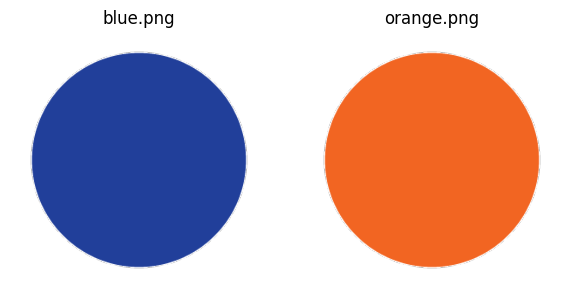

In [9]:
# 이미지 파일 불러오기
blue_img   = Image.open('drive/MyDrive/ICOLSEI_workshop/Analysis/img/blue.png')   # Image.open(): 이미지 파일을 PIL Image 객체로 불러옴
orange_img = Image.open('drive/MyDrive/ICOLSEI_workshop/Analysis/img/orange.png')

print(f'파란 원 이미지 크기: {blue_img.size}')
print(f'주황 원 이미지 크기: {orange_img.size}')

# 두 이미지 나란히 미리보기
fig, axes = plt.subplots(1, 2, figsize=(6, 3))# plt.subplots(행, 열): 그래프 레이아웃 생성
                                              # 1행 2열 = 가로로 두 개 나란히
                                              # figsize=(가로인치, 세로인치)

axes[0].imshow(blue_img)                      # axes[0]: 왼쪽 subplot. imshow(): 이미지를 화면에 표시
axes[0].set_title('blue.png')                 # set_title(): subplot 제목 설정
axes[0].axis('off')                           # axis('off'): 축(눈금, 테두리) 숨기기

axes[1].imshow(orange_img)                    # axes[1]: 오른쪽 subplot
axes[1].set_title('orange.png')
axes[1].axis('off')

plt.tight_layout()                            # subplot 간격 자동 조정 (겹치지 않게)
plt.show()                                    # 그래프를 화면에 출력


---
## Step 5. 실험 화면처럼 이미지 배치하기

실험에서 참가자가 본 화면을 재현한다.
- 파란 원은 **왼쪽**
- 주황 원은 **오른쪽**

`imshow()`의 `extent` 파라미터를 사용해서 이미지를 원하는 좌표 위치에 배치한다.  
extent의 순서: `[x_시작, x_끝, y_끝, y_시작]`

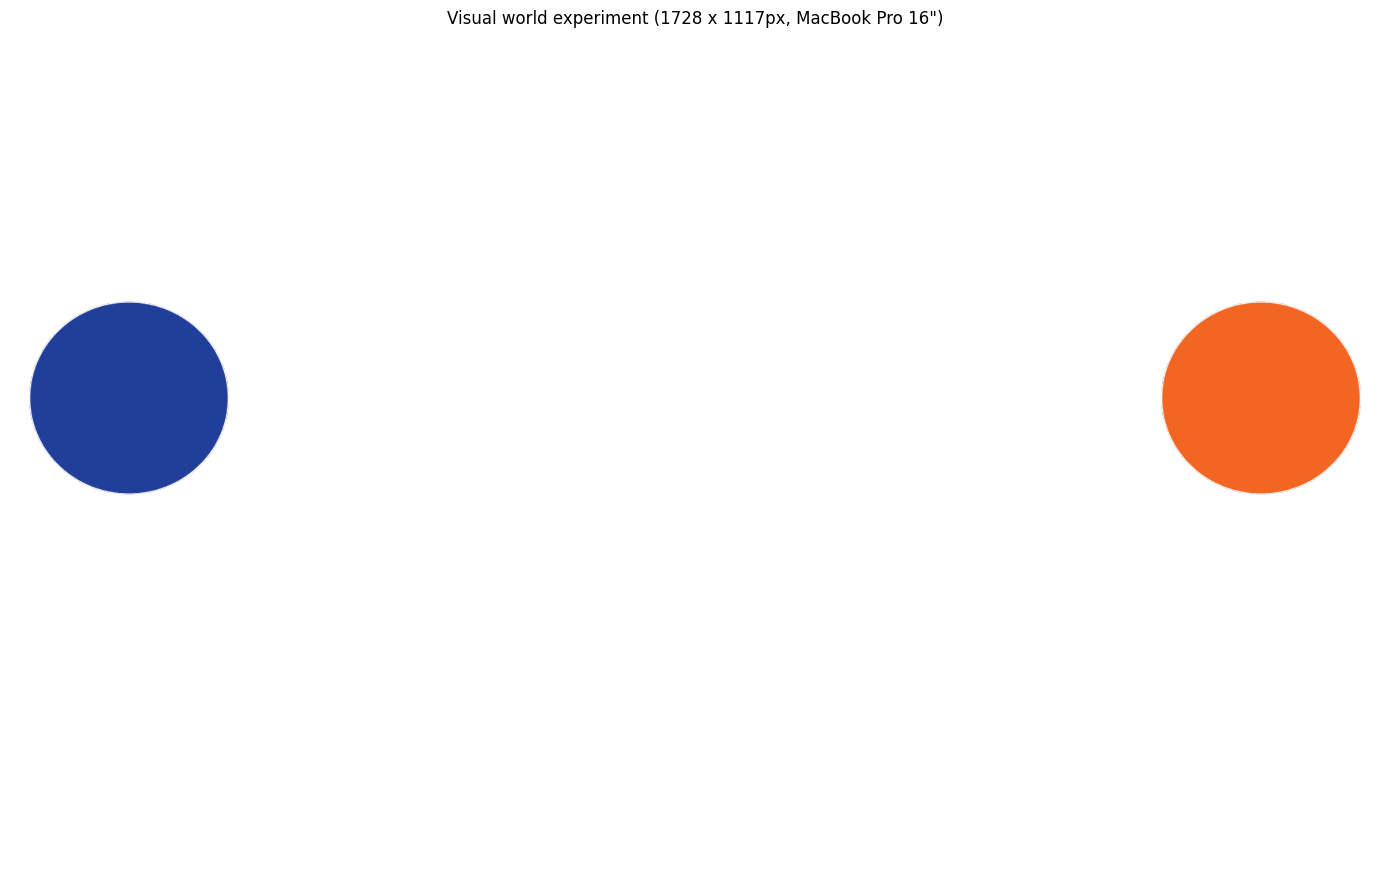

In [10]:
# figsize 계산: 화면 비율(1728:1117)과 동일하게 생성
fig_w = 14                                # 그래프 가로 크기 (인치)
fig_h = fig_w * screen_h / screen_w       # 비율 유지: 14 × (1117/1728) = 9.0인치

# 그래프 캔버스 생성
fig, ax = plt.subplots(figsize=(fig_w, fig_h))  # fig: 전체 그림 객체, ax: 좌표축 객체
ax.set_facecolor('white')                  # 배경색을 흰색으로 설정 (실험 화면 배경과 동일)
ax.set_xlim(0, screen_w)                  # x축 범위: 0 ~ 1728px (화면 너비)
ax.set_ylim(screen_h, 0)                  # y축 범위: 1117 ~ 0.

ax.set_aspect('equal')                    # 가로 1px = 세로 1px 비율 고정

# 파란 원 이미지 배치
ax.imshow(blue_img,
          extent=[blue_pos['left'], blue_pos['right'],   # x 범위: 왼쪽 끝 - 오른쪽 끝
                  blue_pos['bottom'], blue_pos['top']],  # y 범위: 아래 끝 - 위 끝
          aspect='auto')                  # aspect='auto': extent에 맞게 이미지를 늘려서 배치

# 주황 원 이미지 배치
ax.imshow(orange_img,
          extent=[orange_pos['left'], orange_pos['right'],
                  orange_pos['bottom'], orange_pos['top']],
          aspect='auto')

ax.set_title('Visual world experiment (1728 x 1117px, MacBook Pro 16")')
ax.axis('off')                            # 축 숨기기
plt.tight_layout()                        # 여백 자동 조정
plt.show()


---
## Step 6. 시선 이동 경로 그리기

실험 중 참가자의 시선이 어떻게 움직였는지 경로를 그린다.
- 점(scatter)으로 각 시선 위치를 표시
- 선(plot)으로 이동 순서를 연결
- 색상으로 시간의 흐름을 표현 (회색=초반, 검정색=후반)

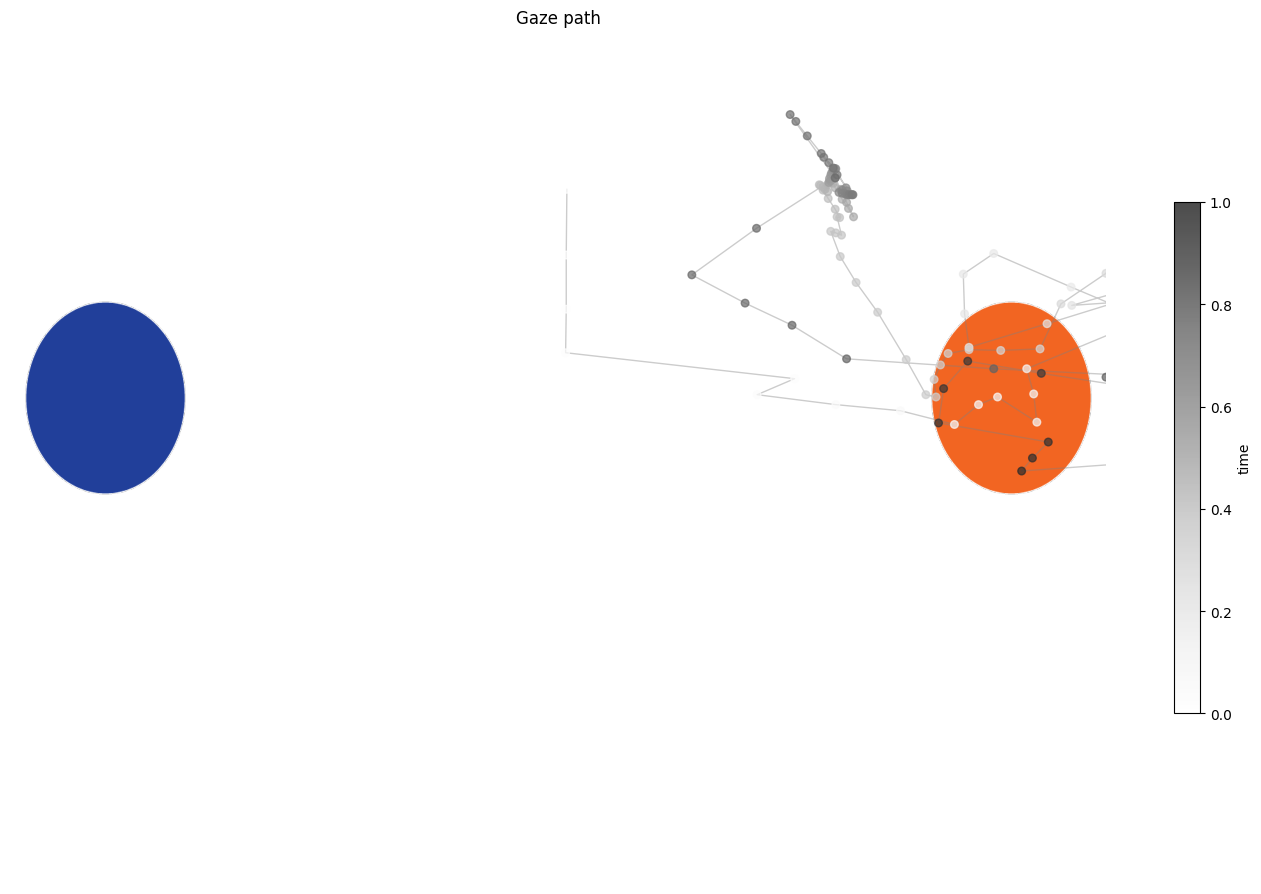

In [11]:
# 그래프 초기 설정 (Step 5와 동일)
fig_w = 14
fig_h = fig_w * screen_h / screen_w      # 화면 비율에 맞는 높이 계산

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.set_facecolor('white')                 # 흰 배경
ax.set_xlim(0, screen_w)                 # x축: 0~1728
ax.set_ylim(screen_h, 0)                 # y축: 1117 ~ 0.
ax.set_aspect('equal')                   # 1:1 비율 고정

# 이미지 배치
ax.imshow(blue_img,
          extent=[blue_pos['left'], blue_pos['right'],
                  blue_pos['bottom'], blue_pos['top']],
          aspect='auto')
ax.imshow(orange_img,
          extent=[orange_pos['left'], orange_pos['right'],
                  orange_pos['bottom'], orange_pos['top']],
          aspect='auto')

# 시선 이동 경로: 연결선
# 정제된 시선 데이터 사용 (화면 밖 시선 제거)
ax.plot(gaze_x_clip, gaze_y_clip, color='gray', alpha=0.4, linewidth=1)
         # ax.plot(): 점들을 순서대로 선으로 연결
         # alpha=0.4: 40% 불투명도 (연하게)
         # linewidth=1: 선 두께 1px

# 시간 정규화: 색상 매핑을 위해 0~1 사이 값으로 변환
t_norm = [(t - gaze_t_clip[0]) / (gaze_t_clip[-1] - gaze_t_clip[0]) for t in gaze_t_clip]
         # 공식: (현재값 - 최솟값) / (최댓값 - 최솟값) -> 항상 0-1 사이
         # 0 = 실험 시작 시점 (가장 밝은 회색)
         # 1 = 실험 종료 시점 (가장 어두운 검정)

# 시선 포인트: 산점도
scatter = ax.scatter(gaze_x_clip, gaze_y_clip,  # x좌표, y좌표 리스트
                     c=t_norm,                   # c: 각 점의 색상 값 (0-1 리스트)
                     cmap='Greys',               # 컬러맵: 밝은 회색(0, 초반) -> 검정(1, 후반)
                     s=30,                       # s: 점의 크기(면적, 단위: 포인트²)
                     alpha=0.7,                  # 70% 투명도
                     zorder=5)                   # zorder: 레이어 순서. 숫자가 클수록 위에 그려짐

plt.colorbar(scatter, ax=ax, label='time', shrink=0.6)
             # colorbar(): 색상이 시간을 의미한다는 범례 막대 추가
             # shrink=0.6: 컬러바 길이를 60%로 줄임
ax.set_title('Gaze path')
ax.axis('off')
plt.tight_layout()
plt.show()


---
## Step 7. 실험 화면 위에 히트맵 합성하기

지금까지 만든 요소를 모두 합쳐서 최종 시각화를 생성한다.

- 배경: 실험 화면 (파란 원 + 주황 원)
- 시각화: 히트맵 (반투명하게 올리기)

`alpha` 값으로 히트맵의 투명도를 조절 (0=완전 투명, 1=완전 불투명)

In [12]:
# 화면 크기와 같은 빈 2D 배열(격자) 생성
# np.zeros((행, 열)): 모든 값이 0인 배열 생성. 각 칸 = 화면의 1픽셀
heatmap_grid = np.zeros((screen_h, screen_w))  # shape: (1117, 1728)

# 각 시선 좌표 위치에 1씩 누적
# 많이 본 픽셀일수록 숫자가 커짐
for x, y in zip(gaze_x_clip, gaze_y_clip):    # 정제된 시선 데이터 사용
    xi, yi = int(x), int(y)                   # float -> int 변환 (배열 인덱스는 정수)
    if 0 <= xi < screen_w and 0 <= yi < screen_h:  # 범위 확인 후 누적
        heatmap_grid[yi, xi] += 1             # 배열은 [행(y), 열(x)] 순서

print(f'시선이 기록된 픽셀 수: {int(np.count_nonzero(heatmap_grid))}개')

# 가우시안 블러로 부드럽게
# sigma: 블러 반경(픽셀). 클수록 더 넓고 부드럽게 퍼짐
heatmap_smooth = gaussian_filter(heatmap_grid, sigma=40)

print('heatmap_smooth 생성 완료:', heatmap_smooth.shape)

시선이 기록된 픽셀 수: 100개
heatmap_smooth 생성 완료: (1117, 1728)


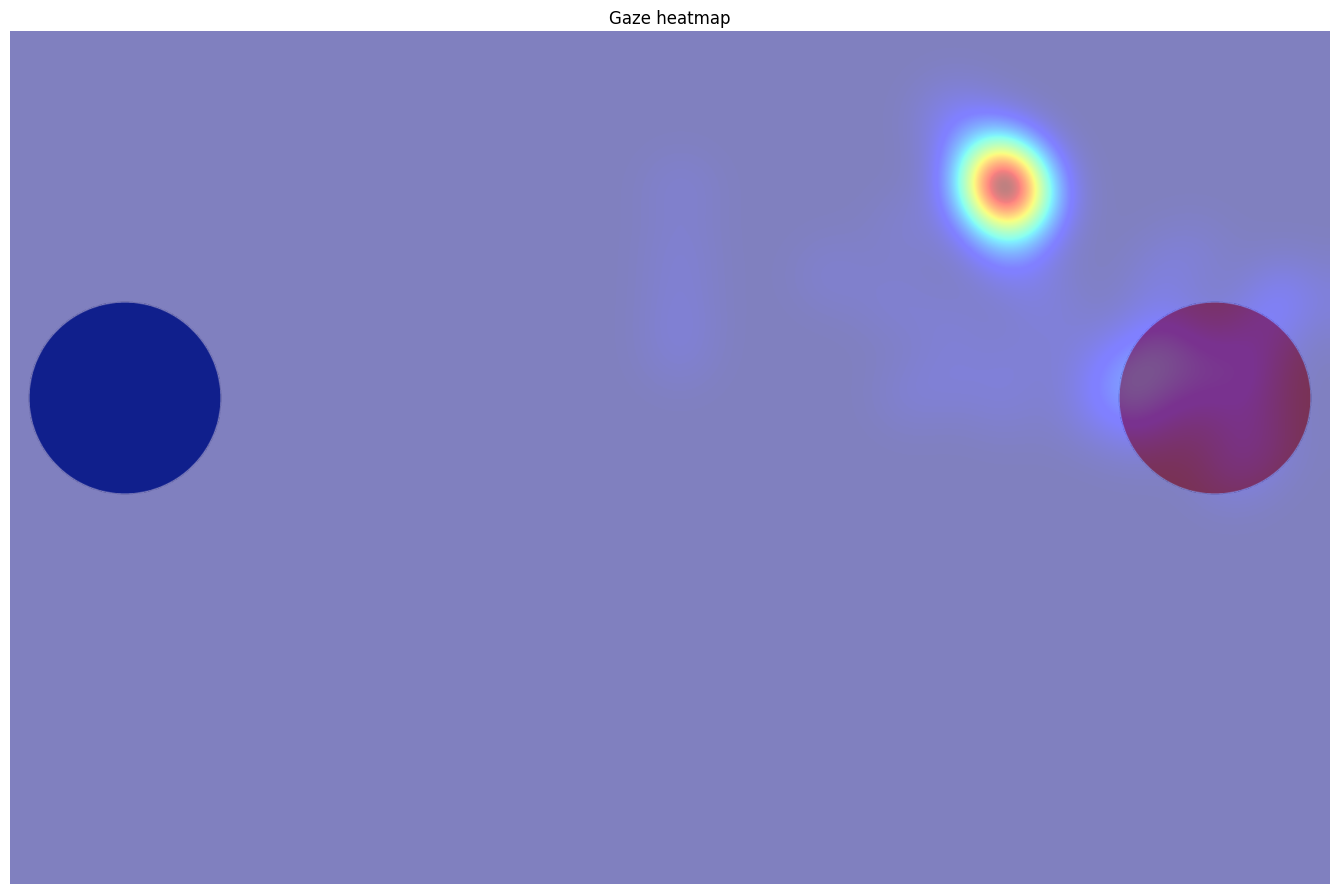

In [13]:
# 그래프 초기 설정
fig_w = 14
fig_h = fig_w * screen_h / screen_w      # 화면 비율 유지

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.set_facecolor('white')
ax.set_xlim(0, screen_w)
ax.set_ylim(screen_h, 0)
ax.set_aspect('equal')

# 레이어 1: 실험 이미지 (가장 아래
ax.imshow(blue_img,
          extent=[blue_pos['left'], blue_pos['right'],
                  blue_pos['bottom'], blue_pos['top']],
          aspect='auto', zorder=1)        # zorder=1: 맨 아래 레이어
ax.imshow(orange_img,
          extent=[orange_pos['left'], orange_pos['right'],
                  orange_pos['bottom'], orange_pos['top']],
          aspect='auto', zorder=1)

# 레이어 2: 히트맵 (이미지 위에 반투명하게)
ax.imshow(heatmap_smooth,                 # 가우시안 블러가 적용된 2D 배열
          extent=[0, screen_w, screen_h, 0],  # 화면 전체 영역에 맞게 펼침
                                          # [x_min, x_max, y_max, y_min] 순서
          cmap='jet',                     # 컬러맵: 파란색(낮음) → 초록 → 빨간색(높음)
          alpha=0.5,                      # 50% 투명도: 아래 이미지가 비쳐 보임
          origin='upper',                 # 배열의 [0,0]을 왼쪽 위에 배치 (화면 좌표계와 일치)
          zorder=2)                       # zorder=2: 이미지(zorder=1) 위에 그려짐

ax.set_title('Gaze heatmap')
ax.axis('off')
plt.tight_layout()
plt.show()
